In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Data Loading
df = pd.read_csv("your_data.csv")

# remove useless column
df = df.drop(columns=["Unnamed: 0"])

df.head()

,fasting blood sugar,age,triglyceride,systolic,relaxation,ALT,HDL,eyesight(left),weight(kg),AST,smoking
0,94,55,300,135,87,25,40,0.5,60,22,1
1,147,70,55,146,83,23,57,0.6,65,27,0
2,79,20,197,118,75,31,45,0.4,75,27,1
3,91,35,203,131,88,27,38,1.5,95,20,0
4,91,30,87,121,76,13,44,1.5,60,19,1


### Univariate Analysis
We analyze each feature individually to understand its distribution. 
This helps identify skewness, spread, and general behavior of each variable in the dataset.

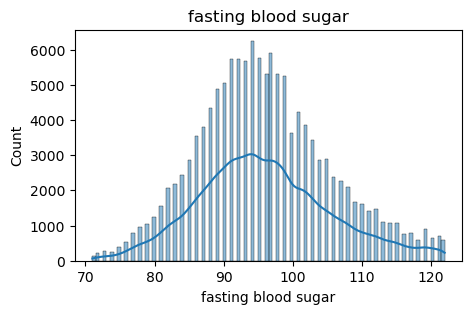

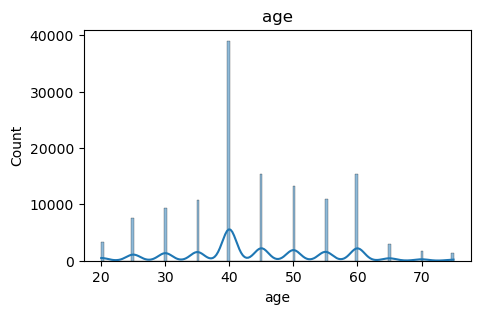

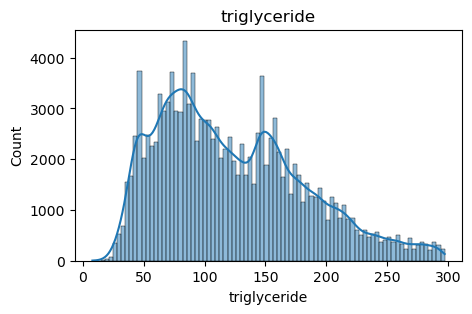

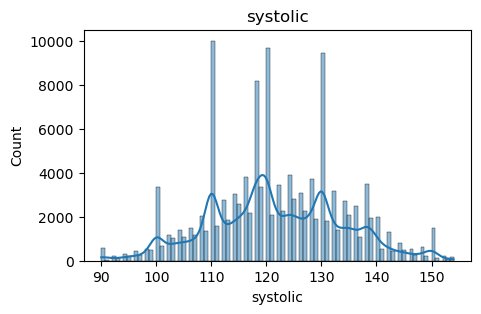

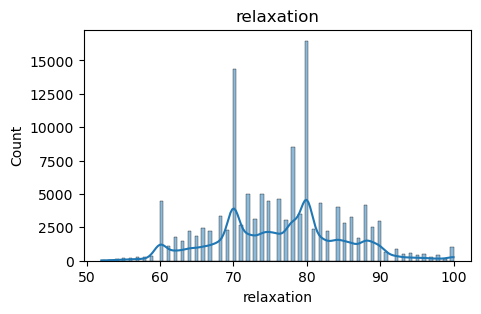

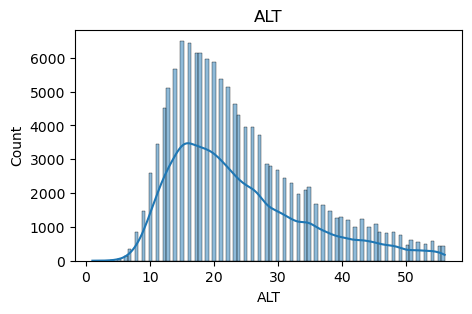

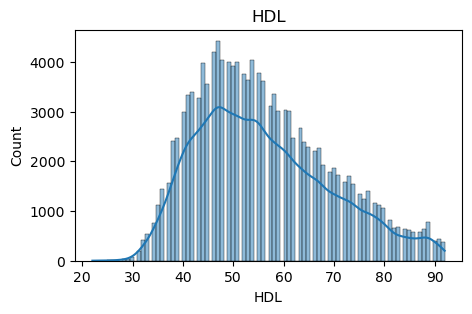

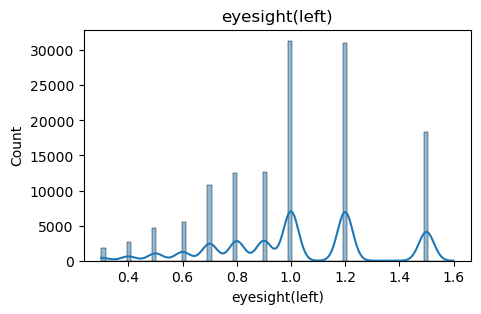

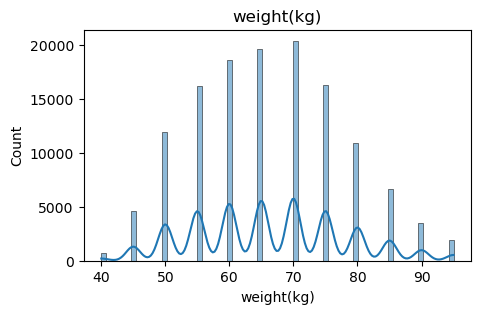

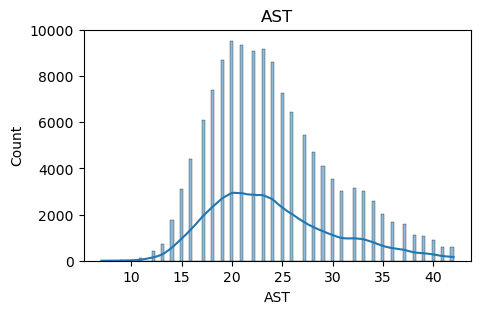

In [20]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,3))
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()

### Outlier Detection
Boxplots are used to detect outliers in each feature. 
Outliers are extreme values that may affect model performance and need to be handled during preprocessing.

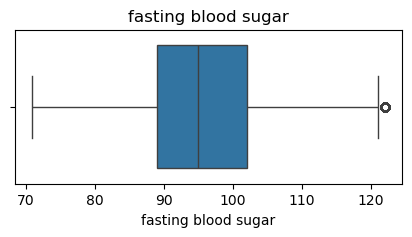

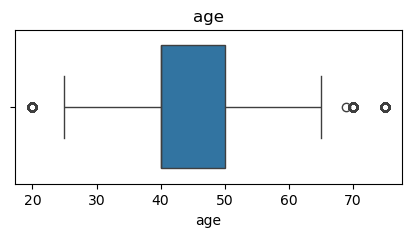

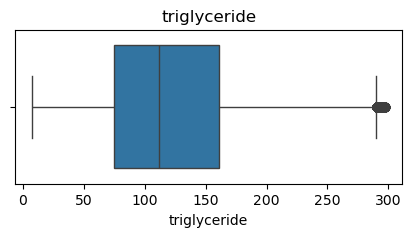

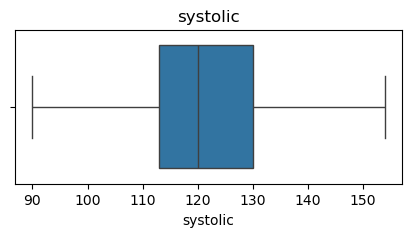

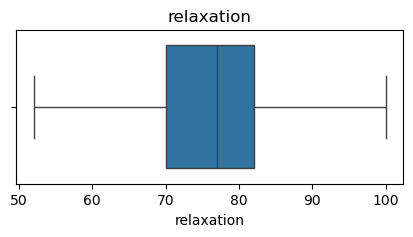

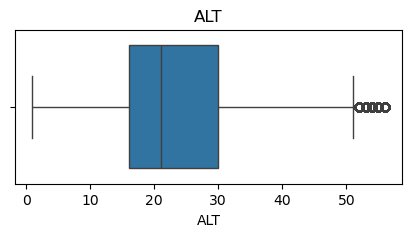

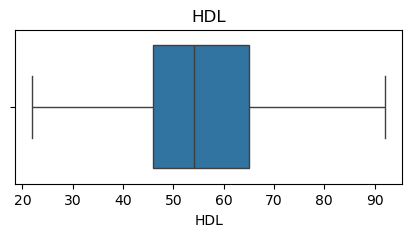

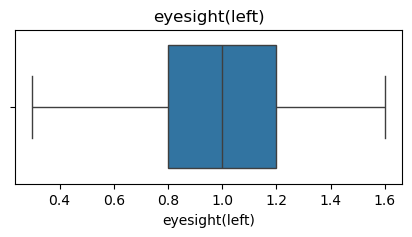

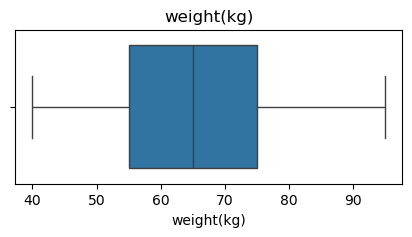

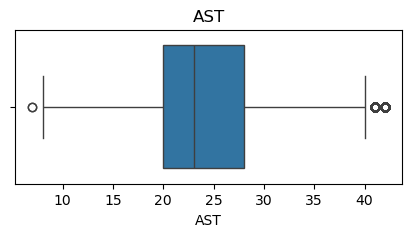

In [21]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,2))
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

### Bivariate Analysis
We study the relationship between each feature and the target variable (smoking). 
This helps identify how different variables vary between smokers and non-smokers.

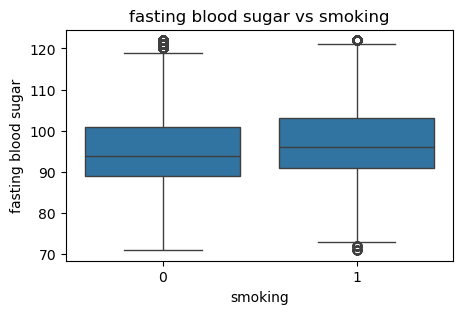

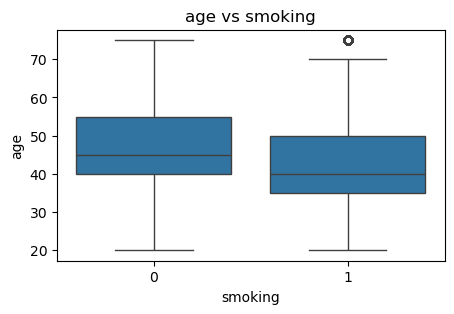

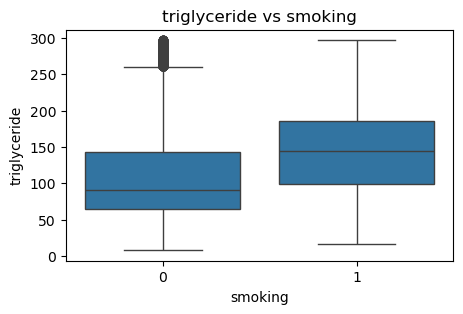

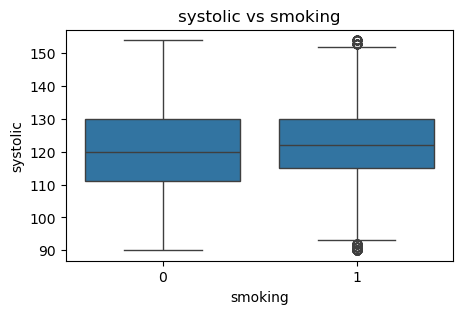

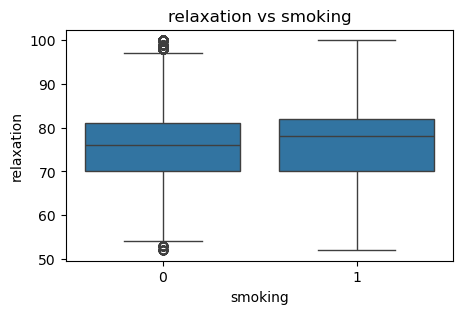

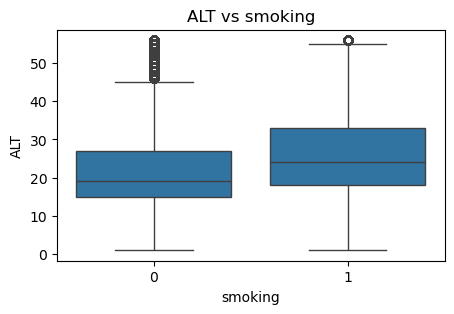

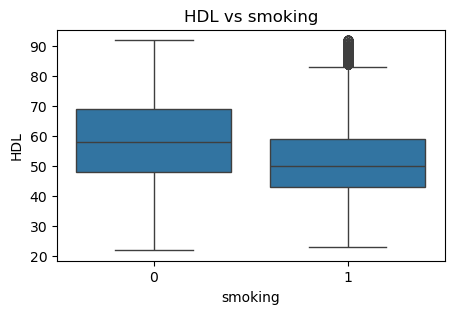

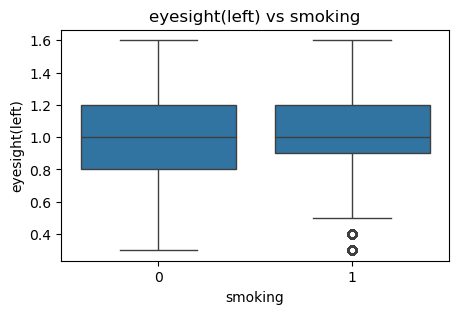

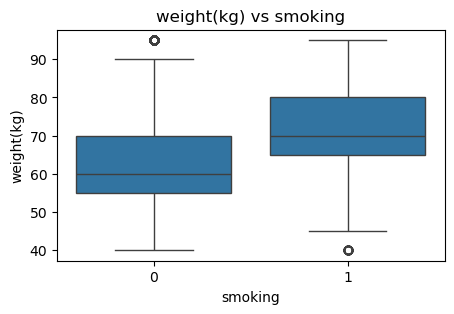

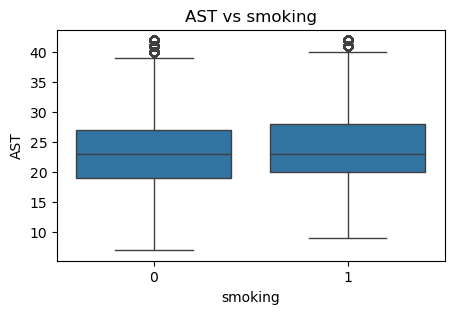

In [22]:
for col in df.columns:
    if col != "smoking":
        plt.figure(figsize=(5,3))
        sns.boxplot(x="smoking", y=col, data=df)
        plt.title(f"{col} vs smoking")
        plt.show()

### Correlation Analysis
A correlation heatmap is used to measure relationships between numerical features. 
It helps identify highly correlated variables that may provide similar information.

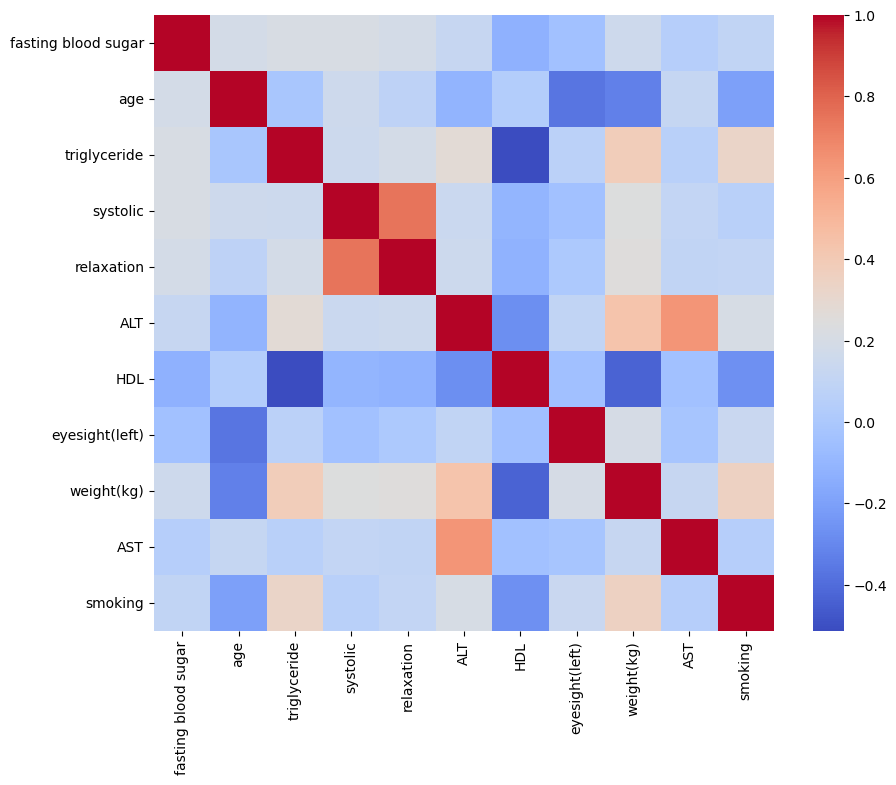

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.show()

### Multivariate Analysis
We use pairplots to visualize relationships between multiple features simultaneously. 
This helps in understanding complex interactions between variables.

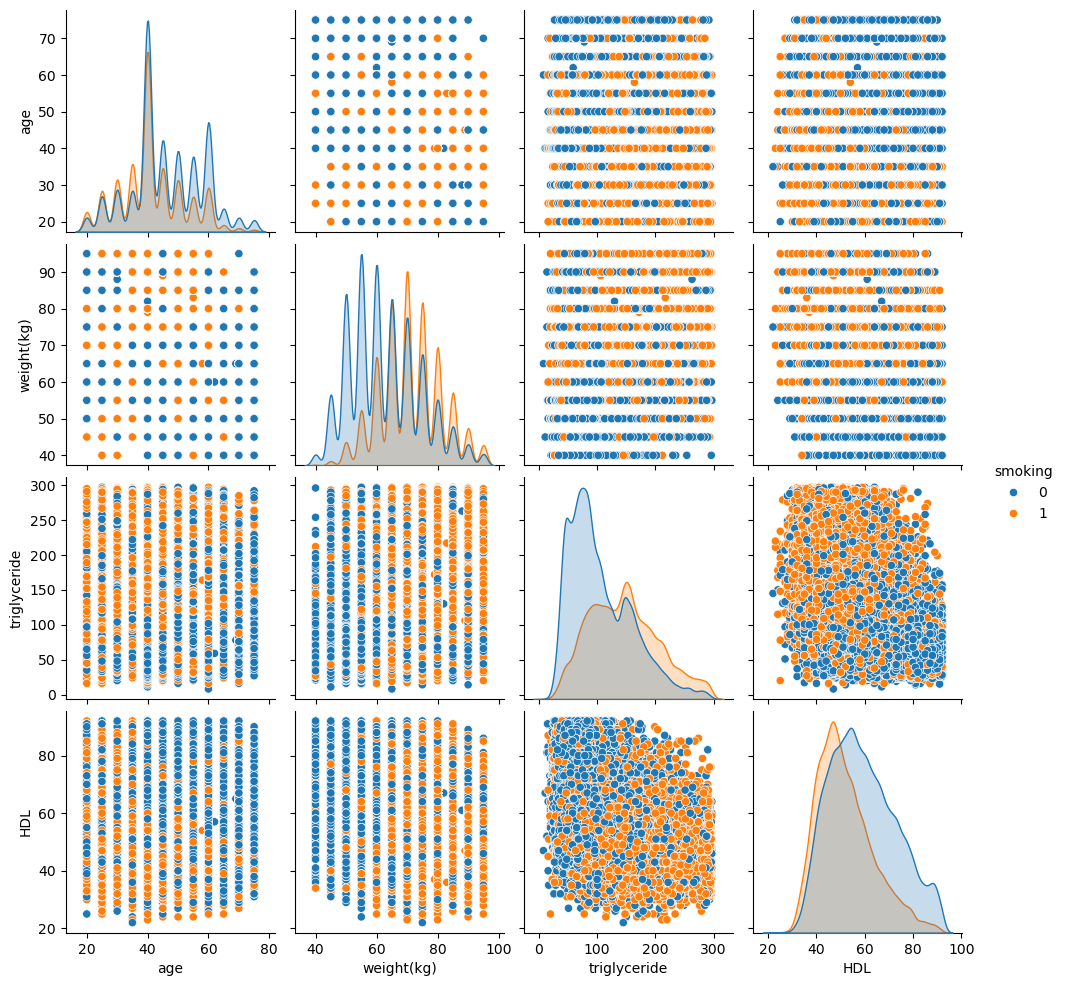

In [24]:
sns.pairplot(df[["age","weight(kg)","triglyceride","HDL","smoking"]],
             hue="smoking")
plt.show()

### Outlier Removal
We apply the IQR method to remove extreme values from the dataset. 
This improves model stability and prevents bias caused by abnormal data points.

In [25]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [26]:
X = df.drop("smoking", axis=1)
y = df["smoking"]

### Feature Scaling
We apply standardization to normalize feature values to the same scale. 
This ensures that all features contribute equally to the model.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Data Splitting
The dataset is split into training and testing sets. 
The training set is used to build the model, while the testing set is used to evaluate its performance.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression Model
A logistic regression model is trained as a simple linear classification approach. 
It models the probability of smoking based on input features.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### Model Evaluation
We evaluate the model using accuracy, precision, recall, and F1-score. 
These metrics help assess the model's classification performance from different perspectives.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.6902706292545243
Precision: 0.6423154137854116
Recall: 0.5750948671859397
F1-score: 0.6068493150684932


### Feature Importance
The coefficients of the logistic regression model are analyzed to understand feature importance. 
Positive values increase the likelihood of smoking, while negative values decrease it.

In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
importance

,Feature,Coefficient
2,triglyceride,0.472356
8,weight(kg),0.455753
4,relaxation,0.138220
0,fasting blood sugar,0.112186
7,eyesight(left),0.083777
5,ALT,0.045522
9,AST,0.039537
3,systolic,-0.142009
6,HDL,-0.182569
1,age,-0.262326
